In [1]:
import torch
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from tqdm import tqdm

# --- Import from your custom modules ---
# Make sure these files are in the same directory or accessible in the Python path
from dataset.generate_training_data import prepare_dataloaders, get_adjacency_matrix_and_supports
from model.model import gwnet_new # Assuming you are using the 'nhat' model which corresponds to gwnet_new
from model.graph_wavenet import gwnet
plt.rcParams['font.size'] = 30

# --- Configuration ---
# Copied from your train.py for consistency
class TrainingConfig:
    seq_len = 30
    pred_len = 10
    num_target_features = 1
    in_feat = 1
    hid_feat = 64
    device = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")
    num_epochs = 50
    batch_size = 32
    learning_rate = 1e-4
    
    MODEL = "nhat"
    DATASET = "ours"
    PROCESSED_DATA_DIR = Path(f"dataset/test_{MODEL}_processed_masked")
    BEST_MODEL_SAVE_PATH = f"weights/ours/test_{MODEL}_model_masked.pt"
    INPUT_DATA_DIR = "dataset/data"
        
    TRAIN_RATIO = 0.7
    VAL_RATIO = 0.15
    USE_RAINFALL = False
    USE_STATIC_FEATURES = False
    USE_ALL_FORCINGS = False
    USE_DISCHARGE_ONLY = True
    USE_GRAPH = True
    LOG_TRANSFORM = True

# Instantiate the configuration
config = TrainingConfig()
print(f"Using device: {config.device}")
print(f"Model path: {config.BEST_MODEL_SAVE_PATH}")

/aul/homes/nhoan009/discharge_forecast/.venv/lib64/python3.11/site-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /lib64/libc.so.6: version `GLIBC_2.32' not found (required by /a/bear.cs.fiu.edu./disk/bear-b/users/nhoan009/discharge_forecast/.venv/lib/python3.11/site-packages/torch_scatter/_version_cuda.so)
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
/aul/homes/nhoan009/discharge_forecast/.venv/lib64/python3.11/site-packages/torch_geometric/typing.py:97: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: /lib64/libc.so.6: version `GLIBC_2.32' not found (required by /a/bear.cs.fiu.edu./disk/bear-b/users/nhoan009/discharge_forecast/.venv/lib/python3.11/site-packages/torch_cluster/_version_cuda.so)
  warnings.warn(f"An issue occurred while importing 'torch-cluster'. "
/aul/homes/nhoan009/discharge_forecast/.venv/lib64/python3.11/

Using device: cuda:2
Model path: weights/ours/test_nhat_model_masked.pt


In [2]:
# Load the dataloaders, adjacency matrix, etc.
train_loader, val_loader, test_loader, adj_matrix, _ = prepare_dataloaders(config=config)

# --- Load the Model ---
num_nodes = adj_matrix.shape[0]
x_sample, _, _, _ = next(iter(test_loader))
num_input_features = x_sample.shape[3]
_, supports = get_adjacency_matrix_and_supports(adj_matrix, config.device)

print(f"Input features shape: {x_sample.shape}")
if config.MODEL == "gwnet":
    model = gwnet(
        device=config.device,
        num_nodes=num_nodes,
        in_dim=num_input_features,
        out_dim=config.pred_len,
        supports=supports
    ).to(config.device)
elif config.MODEL == "nhat":    
    model = gwnet_new(
        device=config.device,
        num_nodes=num_nodes,
        in_dim=num_input_features,
        out_dim=config.pred_len,
        supports=supports
    ).to(config.device)
# Load the trained model weights
print(f"Loading model weights from {config.BEST_MODEL_SAVE_PATH}...")
model.load_state_dict(torch.load(config.BEST_MODEL_SAVE_PATH, map_location=config.device))
model.eval()
print("Model loaded successfully.")

--- Loading and Aligning Data ---
LOADED DISCHARGE PIVOT from dataset/data/usgs_discharge.csv  siteCode    01367690  01367800  01367805  01377000  01377370  01377500  \
dateTime                                                                 
1990-01-01       NaN       NaN       NaN     120.0       NaN      42.0   
1990-01-02       NaN       NaN       NaN     111.0       NaN      30.0   
1990-01-03       NaN       NaN       NaN     108.0       NaN      27.0   
1990-01-04       NaN       NaN       NaN     109.0       NaN      27.0   
1990-01-05       NaN       NaN       NaN     109.0       NaN      27.0   

siteCode    01378500  01379000  01379500  01379530  ...  0146587310  01466500  \
dateTime                                            ...                         
1990-01-01      0.71      41.0     168.0       NaN  ...         NaN       2.4   
1990-01-02      0.63      46.0     160.0       NaN  ...         NaN       2.3   
1990-01-03      0.44      36.0     106.0       NaN  ...       

In [3]:
# Create a background dataset from the training loader
background_data = []
for x, _, _, _ in train_loader:
    background_data.append(x.permute(0, 3, 2, 1))
    if len(background_data) * config.batch_size >= 100: # Use ~200 samples for background
        break
background_data = torch.cat(background_data, dim=0).to(config.device)

# Create a test dataset for explanation from the test loader
test_data = []
for x, _, _, _ in test_loader:
    test_data.append(x.permute(0, 3, 2, 1))
    if len(test_data) * config.batch_size >= 100: # Explain ~100 samples
        break
test_data = torch.cat(test_data, dim=0).to(config.device)

print(f"Background data shape: {background_data.shape}")
print(f"Test data shape: {test_data.shape}")

Background data shape: torch.Size([128, 1, 109, 30])
Test data shape: torch.Size([128, 1, 109, 30])


In [4]:
# The SHAP explainer needs a function that takes a tensor and returns a tensor of predictions.
# Our model expects input of shape (batch, features, nodes, seq_len).

class GwnetModelWrapper(torch.nn.Module):
    """
    Wraps the gwnet model to handle input permutation and select a single output for SHAP.
    This is adapted to handle both grouped and individual site analysis.
    """
    def __init__(self, model, node_index=None):
        super(GwnetModelWrapper, self).__init__()
        self.model = model
        self.node_index = node_index # If None, explains the mean output. If set, explains a specific node.

    def forward(self, x):
        # x = x.permute(0, 3, 2, 1)
        output = self.model(x).squeeze(1)
        return output.mean(dim=1).mean(dim=1).unsqueeze(1)
    
wrapped_model = GwnetModelWrapper(model)
# Initialize the DeepExplainer
# We provide the model (via the predict function) and the background data
explainer = shap.DeepExplainer(wrapped_model, background_data)

# Calculate SHAP values for the test data
print("Calculating SHAP values... (This may take a while)")
shap_values = explainer.shap_values(test_data, check_additivity=False)
print("SHAP values calculated: ", shap_values.shape)

Calculating SHAP values... (This may take a while)


/aul/homes/nhoan009/discharge_forecast/.venv/lib64/python3.11/site-packages/shap/explainers/_deep/deep_pytorch.py:255: UserWarning: unrecognized nn.Module: nconv
  warnings.warn(f"unrecognized nn.Module: {module_type}")


SHAP values calculated:  (128, 1, 109, 30, 1)


In [5]:
# The shap_values have shape (batch_size, seq_len, num_nodes, num_features)
# We want a single importance value per feature for each node (basin).
# We take the mean of the absolute SHAP values across the batch and time dimensions.
print(shap_values.shape)
mean_abs_shap = np.abs(shap_values).mean(axis=(0, 1)).transpose(1, 0, 2)
print(f"Aggregated SHAP values shape: {mean_abs_shap.shape}")

# The resulting shape is (num_nodes, num_features), perfect for a heatmap.
# print(mean_abs_shap)
# To make the plot readable like the example, let's select the top 50 basins
# with the highest overall feature attribution.
total_attribution_per_basin = mean_abs_shap.sum(axis=0)
print(f"total_attribution_per_basin: {total_attribution_per_basin.shape}")

top_50_indices = np.argsort(total_attribution_per_basin.squeeze())[-50:]

# Filter the SHAP values and get the corresponding basin indices for labeling
top_50_shap_values = mean_abs_shap.transpose(1, 0, 2)[top_50_indices]
top_50_basin_labels = top_50_indices
print(f"Top 50 basin indices: {top_50_basin_labels}")
print(f"top_50_shap_values: {top_50_shap_values.shape}")

(128, 1, 109, 30, 1)
Aggregated SHAP values shape: (30, 109, 1)
total_attribution_per_basin: (109, 1)
Top 50 basin indices: [  6  95  93  66  24  18  55  63  78  48  22  45  16 102  75   9  10  28
  13 101   3  44 105   4  92  20  86  56  94  83  52  67  42  65  85  98
  64  31  14  25  88  15  71  17  23  72  49  89   8  29]
top_50_shap_values: (50, 30, 1)


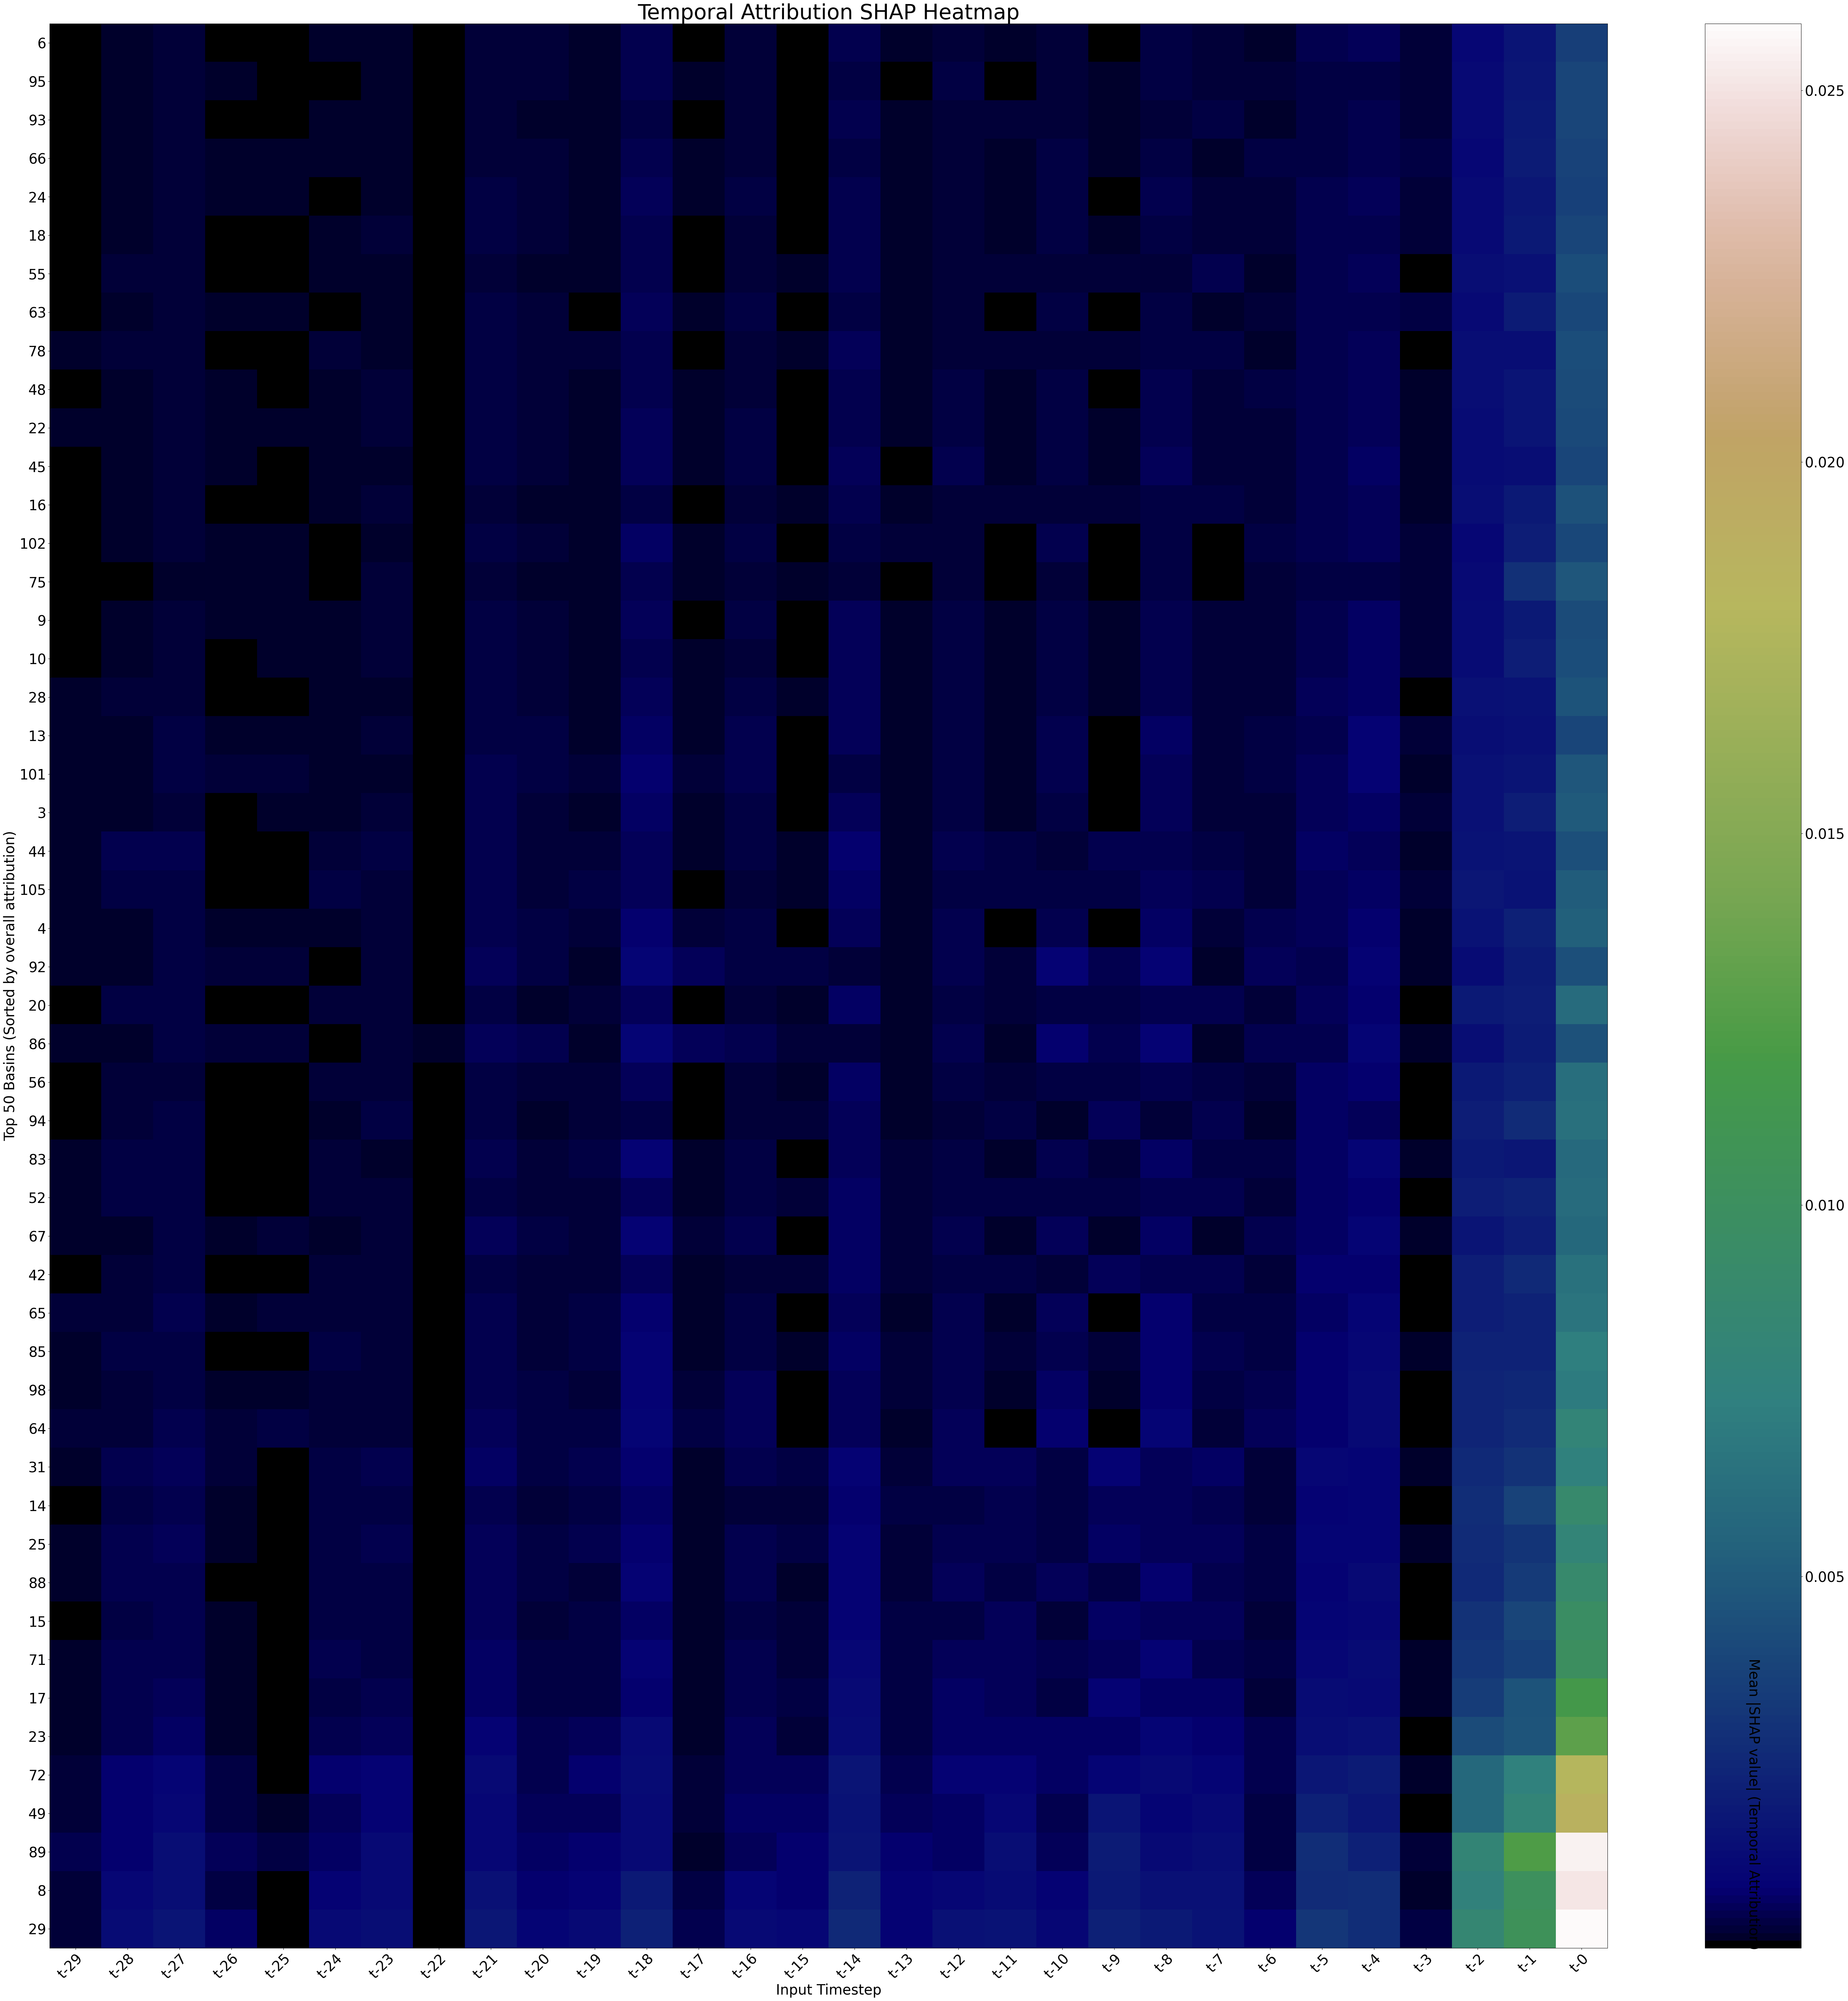

In [6]:
# Define feature names based on the order they are stacked in generate_training_data.py
# This order is crucial and must match your data preparation logic.
dynamic_features = ['Discharge', 'Rainfall']
static_features = [
    "CSL10_85","APRAVPRE","CONLENLDR","DRNAREA","FOREST","JUNAVPRE","PERMSSUR","POPDENS","SLOPLAGPER","STORAGE"
]
# This logic needs to match what your config does.
if config.USE_DISCHARGE_ONLY and not config.USE_RAINFALL:
    feature_names = ['Discharge']
elif config.USE_RAINFALL:
    feature_names = ['Discharge', 'Rainfall'] # Assuming this is the order
    
if config.USE_STATIC_FEATURES:
    feature_names.extend(static_features)
fig, ax = plt.subplots(figsize=(60, 60))

# Use imshow to create the heatmap. Data shape is (timesteps, basins)
im = ax.imshow(top_50_shap_values, cmap='gist_earth', aspect='auto')

# Create colorbar
cbar = ax.figure.colorbar(im, ax=ax)
cbar.ax.set_xlabel("Mean |SHAP value| (Temporal Attribution)", rotation=-90, va="bottom")

# Set up timestep labels for the y-axis
seq_len = top_50_shap_values.shape[1]
x_labels = [f"t-{seq_len-i-1}" for i in range(seq_len)]

# Set ticks and labels
ax.set_yticks(np.arange(len(top_50_basin_labels)))
ax.set_xticks(np.arange(seq_len))
ax.set_yticklabels(top_50_basin_labels)
ax.set_xticklabels(x_labels)
ax.set_ylabel("Top 50 Basins (Sorted by overall attribution)")
ax.set_xlabel("Input Timestep")

# Rotate the x-axis tick labels for readability
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

ax.set_title("Temporal Attribution SHAP Heatmap", fontsize = 45)
fig.tight_layout()
plt.show()

SHAP summary bar plot saved to: plots/shap_analysis/feature_importance_summary_bar.png


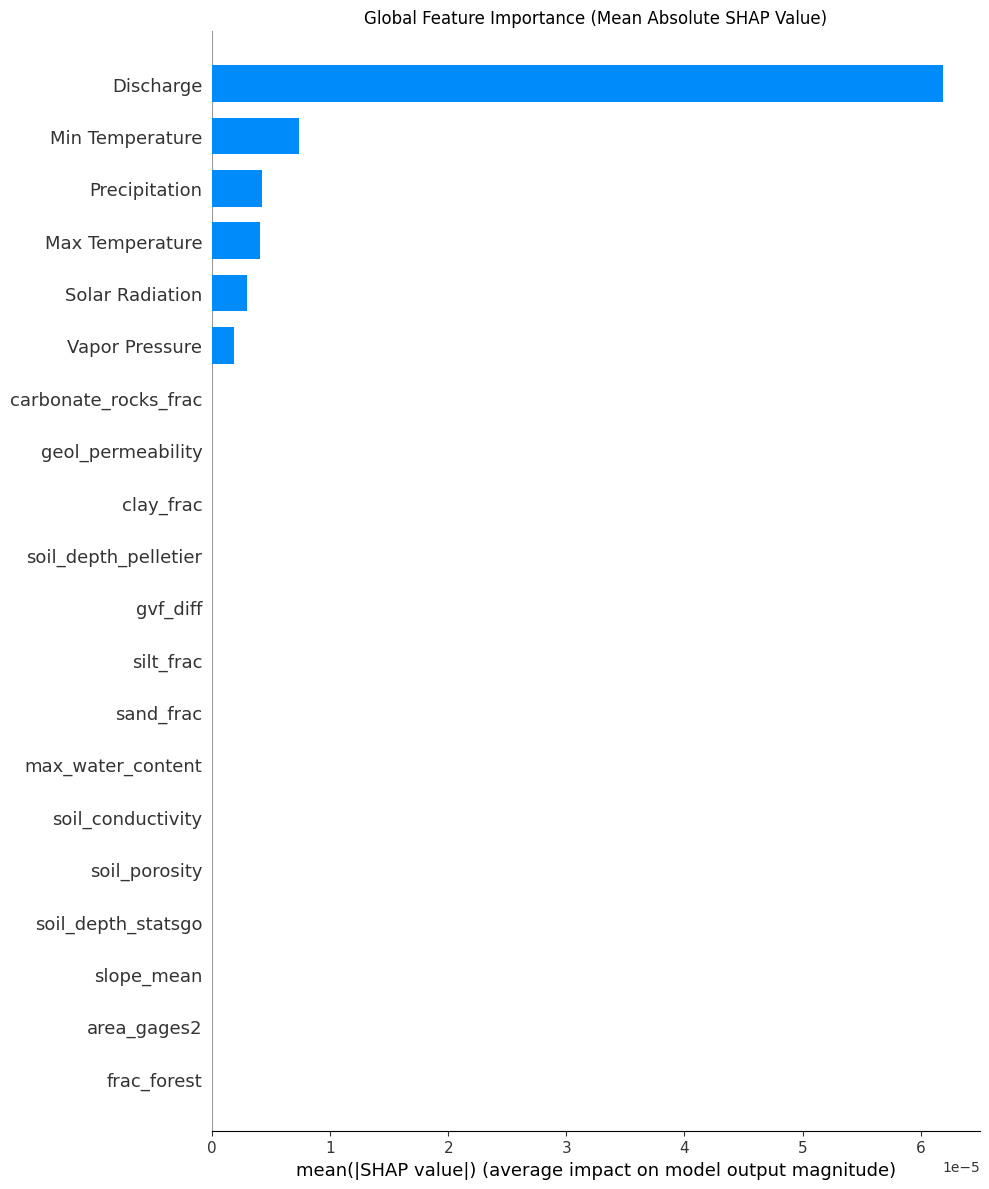

In [ ]:

# Plot 2: Bar Chart Summary Plot
shap.summary_plot(
    shap_values_reshaped,
    test_data_reshaped,
    feature_names=all_feature_names,
    show=False,
    plot_type='bar'
)
plt.gcf().set_size_inches(10, 12)
plt.title("Global Feature Importance (Mean Absolute SHAP Value)")
plt.tight_layout()
save_path = config.SHAP_PLOTS_DIR / "feature_importance_summary_bar.png"
plt.savefig(save_path, dpi=150)
print(f"SHAP summary bar plot saved to: {save_path}")
plt.show()
plt.close()


Temporal importance plot saved to: plots/shap_analysis/temporal_feature_importance.png


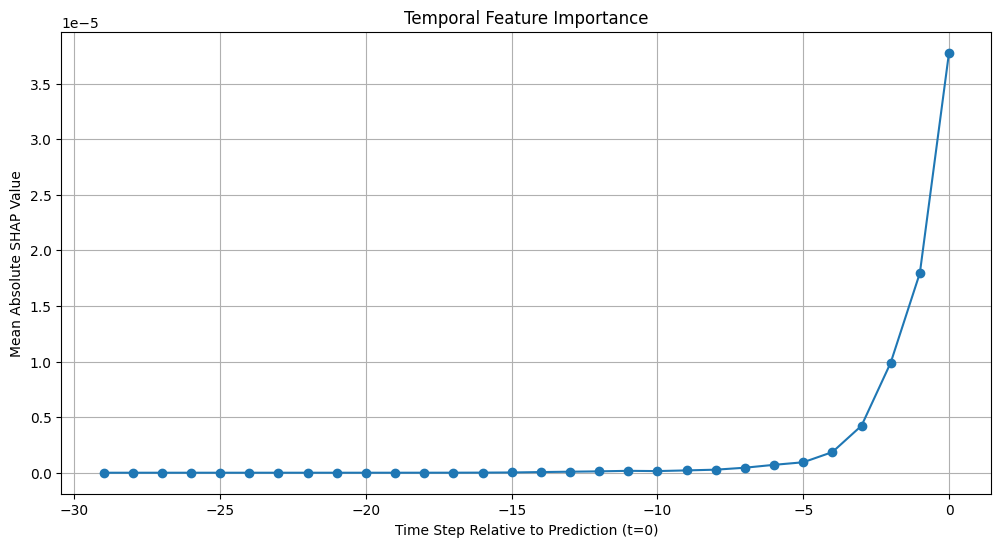

In [ ]:

# Plot 3: Temporal Importance Plot
# Average the absolute SHAP values across samples, nodes, and features for each time step
# Shape of shap_values: (num_samples, seq_len, num_nodes, num_features)
temporal_importance = np.abs(shap_values).mean(axis=(0, 2, 3))
plt.figure(figsize=(12, 6))
time_steps = np.arange(-config.seq_len + 1, 1)
plt.plot(time_steps, temporal_importance, marker='o', linestyle='-')
plt.xlabel("Time Step Relative to Prediction (t=0)")
plt.ylabel("Mean Absolute SHAP Value")
plt.title("Temporal Feature Importance")
plt.grid(True)
save_path = config.SHAP_PLOTS_DIR / "temporal_feature_importance.png"
plt.savefig(save_path, dpi=150)
print(f"Temporal importance plot saved to: {save_path}")
plt.show()
plt.close()


Dynamic vs. static importance plot saved to: plots/shap_analysis/dynamic_vs_static_importance.png


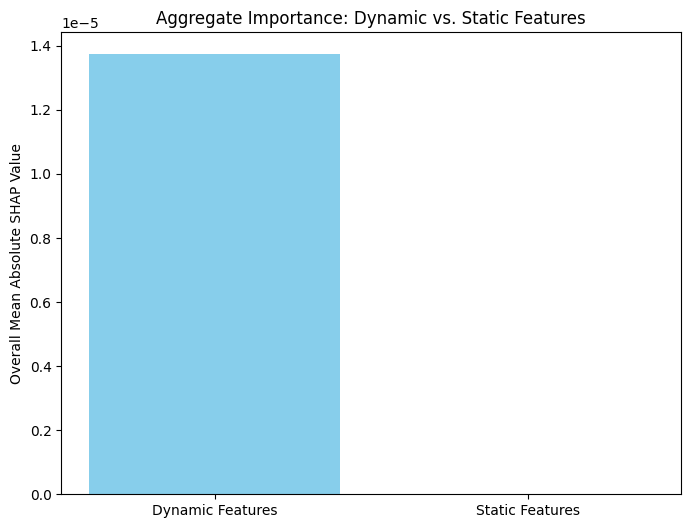


--- SHAP Analysis Complete ---


In [ ]:

# Plot 4: Dynamic vs Static Feature Importance
num_dynamic = len(dynamic_feature_names)
mean_abs_shap_dynamic = np.abs(shap_values_reshaped[:, :num_dynamic]).mean()
mean_abs_shap_static = np.abs(shap_values_reshaped[:, num_dynamic:]).mean()

plt.figure(figsize=(8, 6))
plt.bar(['Dynamic Features', 'Static Features'], [mean_abs_shap_dynamic, mean_abs_shap_static], color=['skyblue', 'salmon'])
plt.ylabel("Overall Mean Absolute SHAP Value")
plt.title("Aggregate Importance: Dynamic vs. Static Features")
save_path = config.SHAP_PLOTS_DIR / "dynamic_vs_static_importance.png"
plt.savefig(save_path, dpi=150)
print(f"Dynamic vs. static importance plot saved to: {save_path}")
plt.show()
plt.close()

print("\n--- SHAP Analysis Complete ---")


In [ ]:

# Plot 3: Bar Chart Discharge Plot
shap.summary_plot(
    shap_values_reshaped[:, 0],  # Only plot the first feature (Discharge)
    test_data_reshaped[:, 0].reshape(-1, 1),  # Reshape to match
    feature_names=['Discharge'],
    show=False,
    plot_type='bar'
)
plt.gcf().set_size_inches(10, 6)
plt.title("Discharge Feature Importance (Bar Plot)")
plt.tight_layout()
save_path = config.SHAP_PLOTS_DIR / "discharge_feature_importance_bar.png"
plt.savefig(save_path, dpi=150)
print(f"Discharge feature importance bar plot saved to: {save_path}")
plt.show()
plt.close()


AssertionError: Summary plots need a matrix of shap_values, not a vector.